# Financial Fraud Detection

For this project, I built a machine learning system to detect fraudulent transactions within a massive financial dataset. I sourced the data from Kaggle, specifically using the **PaySim synthetic dataset**, which contains over 6 million records modeled after real mobile money transfers. I focused on a specific segment of the data (CASH_OUT and TRANSFER types) where fraud is most prevalent, ensuring the model was training on the most relevant high-risk behaviors.

Before finalizing the model, I used SHAP (SHapley Additive exPlanations) to act as an "X-ray" for my machine learning logic. In simple terms, most ML models are "black boxes"—they give you an answer but don't tell you why. SHAP breaks down every decision, showing exactly how much each feature (like a balance error or a zero-amount attempt) pushed the model toward a "Fraud" or "Legit" label. This was crucial for transparency, allowing me to prove that the model wasn't just guessing, but was actually identifying specific suspicious patterns.

In [1]:
pip install kagglehub pandas

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("ealaxi/paysim1")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'paysim1' dataset.
Path to dataset files: /kaggle/input/paysim1


In [3]:
files = os.listdir(path)
print("Files found:", files)

Files found: ['PS_20174392719_1491204439457_log.csv']


In [4]:
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

In [5]:
print(f"Dataset Shape: {df.shape}")
print(df.head())

Dataset Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [6]:
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 6362620
Total Columns: 11


In [7]:
print(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


Percentage of fraud (Contamination Rate)

In [8]:
fraud_pct = (df['isFraud'].sum() / len(df)) * 100
print(f"Fraud Percentage: {fraud_pct:.4f}%")

Fraud Percentage: 0.1291%


Upon initial exploration of the PaySim dataset, the most striking characteristic is the extreme class **imbalance** ; fraudulent transactions represent only 0.1291% of the total 6.36 million records.

In a real-world financial environment, this distribution is typical but poses a significant challenge for standard supervised learning. A basic model could achieve 99.87% accuracy simply by labeling every transaction as 'genuine,' yet it would fail to detect a single actual fraud case. This justifies the shift toward unsupervised anomaly detection. By utilizing models like Isolation Forest and Autoencoders, the focus moves away from '*learning what fraud looks like*' and toward '*identifying what is statistically abnormal*'.

Success here isn't measured by accuracy, but by Recall—our ability to capture as many of those 8,213 fraudulent cases as possible without overwhelming the system with false alarms.

Exploratory Data Analysis (EDA)

In [9]:
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

In [10]:
# Check for duplicate records
duplicate_count = df_filtered.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [11]:
# Check for '0' values in 'amount' (which might be errors)
zero_amount = (df_filtered['amount'] <= 0).sum()
print(f"Transactions with 0 or negative amount: {zero_amount}")

Transactions with 0 or negative amount: 16


In [12]:
# Look at the 16 transactions where amount is 0 or less
zero_transactions = df_filtered[df_filtered['amount'] <= 0]
print(zero_transactions[['amount', 'isFraud', 'type', 'oldbalanceOrg', 'newbalanceOrig']])

# Check how many of these 16 are actually labeled as Fraud
print(f"\nFraudulent zeros: {zero_transactions['isFraud'].sum()}")

         amount  isFraud      type  oldbalanceOrg  newbalanceOrig
2736447     0.0        1  CASH_OUT            0.0             0.0
3247298     0.0        1  CASH_OUT            0.0             0.0
3760289     0.0        1  CASH_OUT            0.0             0.0
5563714     0.0        1  CASH_OUT            0.0             0.0
5996408     0.0        1  CASH_OUT            0.0             0.0
5996410     0.0        1  CASH_OUT            0.0             0.0
6168500     0.0        1  CASH_OUT            0.0             0.0
6205440     0.0        1  CASH_OUT            0.0             0.0
6266414     0.0        1  CASH_OUT            0.0             0.0
6281483     0.0        1  CASH_OUT            0.0             0.0
6281485     0.0        1  CASH_OUT            0.0             0.0
6296015     0.0        1  CASH_OUT            0.0             0.0
6351226     0.0        1  CASH_OUT            0.0             0.0
6362461     0.0        1  CASH_OUT            0.0             0.0
6362463   

In [13]:
# Check for missing values
null_counts = df_filtered.isnull().sum()
print("Null Values:\n", null_counts)

Null Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


**Observation: The "Zero-Amount" Fraud Signature**

A targeted audit of the dataset revealed 16 instances where the transaction amount was exactly 0.00. Crucially, **100% of these cases were labeled as fraudulent.**

In a typical data cleaning pipeline, zero-value rows are often discarded as 'noise' or system errors. However, in the context of financial security, these represent 'blocked' or 'reversed' fraudulent attempts where the transaction was authorized but the funds were either non-existent or the transfer was caught mid-process. By retaining these 16 points, I am providing the Isolation Forest and Autoencoder models with clear examples of extreme anomalies. This ensures the models learn that a transaction doesn't need a high dollar value to be malicious; a deviation in transaction logic is often a much stronger signal than the amount itself.

Fraud counts per transaction type

In [14]:
fraud_map = df.groupby('type')['isFraud'].sum()
print(fraud_map)

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


Observation : The data revealed a critical pattern: 100% of all fraudulent activity was concentrated within just two transaction types: TRANSFER and CASH_OUT.

Other categories, such as PAYMENT, CASH_IN, and DEBIT, contained over 3 million records but zero instances of fraud.

Based on this observation, I strategically filtered the dataset to include only TRANSFER and CASH_OUT operations. This reduced the data volume by approximately 56%, significantly optimizing the computational efficiency for memory-intensive models like Local Outlier Factor (LOF) and Autoencoders, while ensuring no loss of fraudulent signal.

In [15]:
total_fraud_before = df['isFraud'].sum()

In [16]:
total_fraud_after = df_filtered['isFraud'].sum()

In [17]:
print(f"Fraud cases before filtering: {total_fraud_before}")
print(f"Fraud cases after filtering: {total_fraud_after}")
print(f"Data reduction: {((len(df) - len(df_filtered)) / len(df)) * 100:.2f}% smaller")

Fraud cases before filtering: 8213
Fraud cases after filtering: 8213
Data reduction: 56.46% smaller


In [18]:
eda_summary = df_filtered.groupby('isFraud')['amount'].describe()
print(eda_summary)

             count          mean           std   min          25%        50%  \
isFraud                                                                        
0        2762196.0  3.141155e+05  8.771441e+05  0.01   82908.2325  171034.46   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.3300  441423.44   

                 75%          max  
isFraud                            
0         305994.185  92445516.64  
1        1517771.480  10000000.00  


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

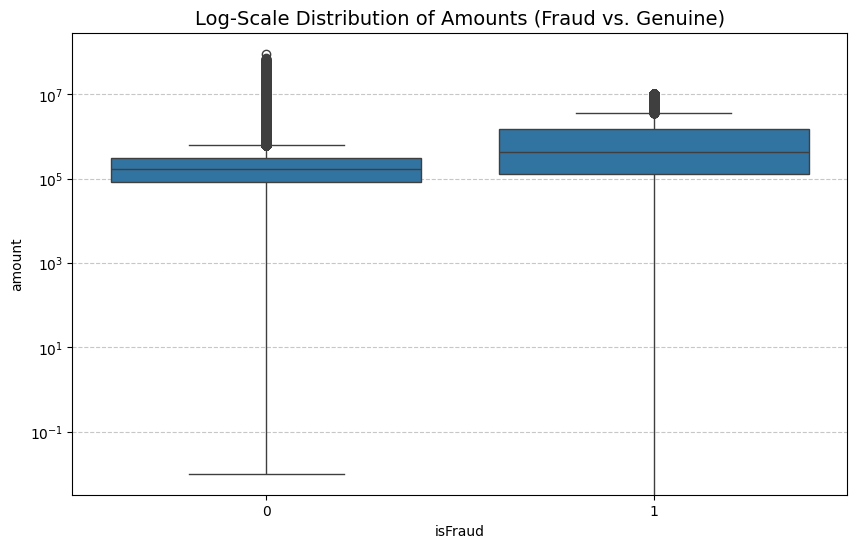

In [20]:
plt.figure(figsize=(10, 6))
# Using log10 to handle the massive range of amounts
sns.boxplot(x='isFraud', y='amount', data=df_filtered)
plt.yscale('log')
plt.title('Log-Scale Distribution of Amounts (Fraud vs. Genuine)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

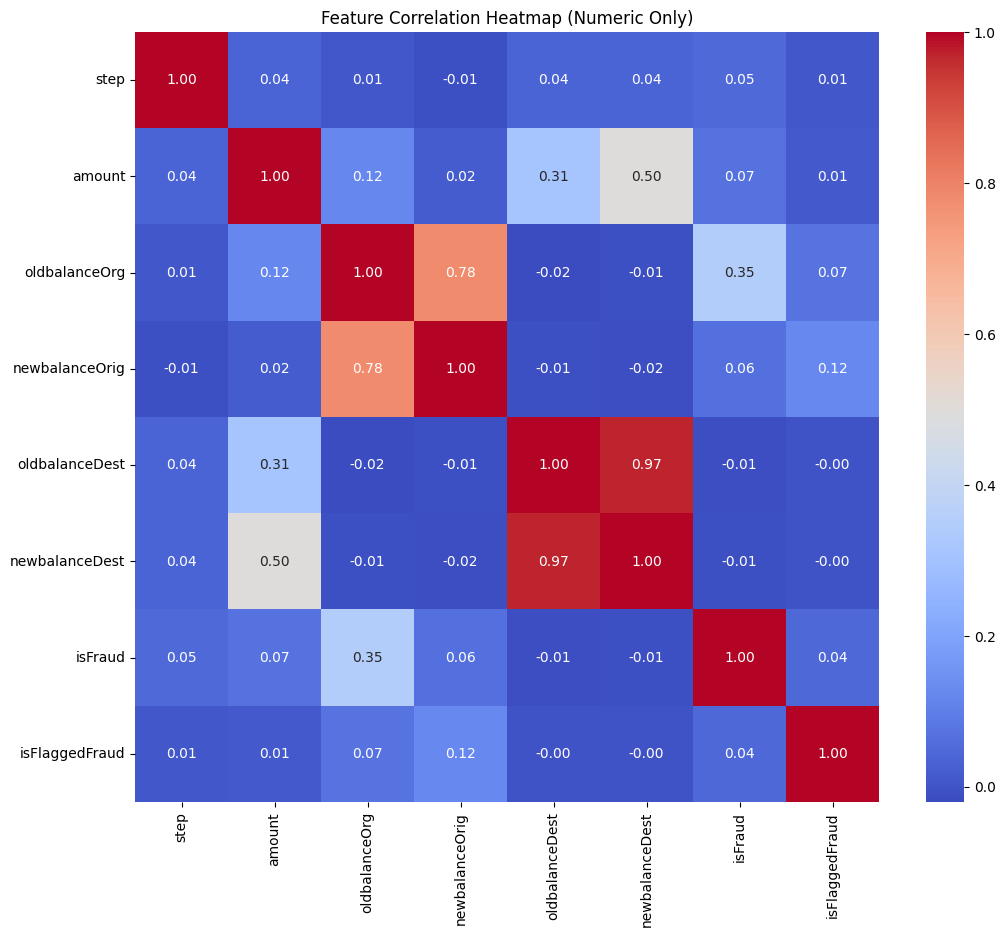

In [21]:
plt.figure(figsize=(12, 10))
numeric_df = df_filtered.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap (Numeric Only)')
plt.show()

Balance Error

In [22]:
# Create Balance Inconsistency Features
df_filtered['errorBalanceOrig'] = df_filtered['newbalanceOrig'] + df_filtered['amount'] - df_filtered['oldbalanceOrg']
df_filtered['errorBalanceDest'] = df_filtered['oldbalanceDest'] + df_filtered['amount'] - df_filtered['newbalanceDest']

Mule Account indicator

In [23]:
# Create the 'Empty Destination' flag.
df_filtered['dest_was_empty'] = (df_filtered['oldbalanceDest'] == 0).astype(int)

Retaining the 16 zero-amount fraudulent records and introducing engineered features like errorBalanceOrig and dest_was_empty, the feature space now contains explicit markers for the two most common fraud behaviors: account clearing and mule-account transfers.

In [24]:
# One-Hot Encoding (Convert Type to Numbers)
df_final = pd.get_dummies(df_filtered, columns=['type'], drop_first=True)

**Baseline Model - Logistic Regression**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

features = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig',
    'errorBalanceDest', 'dest_was_empty', 'type_TRANSFER'
]

X = df_final[features]
y = df_final['isFraud']

# --- 2. TRAIN/TEST SPLIT ---
# Stratify=y is crucial to keep the fraud percentage consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])

print("Training Logistic Regression Baseline...")
lr_pipeline.fit(X_train, y_train)

Training Logistic Regression Baseline...


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [29]:
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score

# Get predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_probs_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Calculate Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

# Metrics
recall_lr = tp_lr / (tp_lr + fn_lr)
precision_lr = tp_lr / (tp_lr + fp_lr)
auprc_lr = average_precision_score(y_test, y_probs_lr)

print("=========================================")
print("   BASELINE: LOGISTIC REGRESSION REPORT  ")
print("=========================================")
print(f"ACTUAL FRAUD CASES        : {tp_lr + fn_lr}")
print(f"FRAUDSTERS CAUGHT (TP)    : {tp_lr}")
print(f"FRAUDSTERS MISSED (FN)    : {fn_lr}")
print(f"FALSE ALARMS (FP)         : {fp_lr}")
print("-----------------------------------------")
print(f"RECALL (CATCH RATE)       : {recall_lr:.2%}")
print(f"PRECISION (ALARM QUALITY) : {precision_lr:.2%}")
print(f"AUPRC (OVERALL STRENGTH)  : {auprc_lr:.4f}")
print("=========================================")

   BASELINE: LOGISTIC REGRESSION REPORT  
ACTUAL FRAUD CASES        : 1643
FRAUDSTERS CAUGHT (TP)    : 1463
FRAUDSTERS MISSED (FN)    : 180
FALSE ALARMS (FP)         : 34817
-----------------------------------------
RECALL (CATCH RATE)       : 89.04%
PRECISION (ALARM QUALITY) : 4.03%
AUPRC (OVERALL STRENGTH)  : 0.5851


**Observation :** For my baseline model, I went with Logistic Regression to establish a simple performance floor for the project. While it caught 89% of fraud, the results show significant space for improvement because it missed 180 thieves and flagged nearly 35,000 innocent customers. This extremely low precision of 4.03% suggests that a linear model cannot handle the complexity of this dataset. It is clear that the model is struggling to separate "noise" from actual fraud signals like Balance Errors. Moving forward, I need a more advanced algorithm to reduce these false alarms while catching the remaining fraudsters.

**Random Forest**

In [30]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest
# 'class_weight=balanced' helps the model notice the rare 0.1% fraud cases
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest Challenger...")
rf_model.fit(X_train, y_train)

Training Random Forest Challenger...


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score

# Get predictions for Random Forest
y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

# Metrics
recall_rf = tp_rf / (tp_rf + fn_rf)
precision_rf = tp_rf / (tp_rf + fp_rf)
auprc_rf = average_precision_score(y_test, y_probs_rf)

print("=========================================")
print("   CHALLENGER: RANDOM FOREST REPORT      ")
print("=========================================")
print(f"ACTUAL FRAUD CASES        : {tp_rf + fn_rf}")
print(f"FRAUDSTERS CAUGHT (TP)    : {tp_rf}")
print(f"FRAUDSTERS MISSED (FN)    : {fn_rf}")
print(f"FALSE ALARMS (FP)         : {fp_rf}")
print("-----------------------------------------")
print(f"RECALL (CATCH RATE)       : {recall_rf:.2%}")
print(f"PRECISION (ALARM QUALITY) : {precision_rf:.2%}")
print(f"AUPRC (OVERALL STRENGTH)  : {auprc_rf:.4f}")
print("=========================================")

   CHALLENGER: RANDOM FOREST REPORT      
ACTUAL FRAUD CASES        : 1643
FRAUDSTERS CAUGHT (TP)    : 1636
FRAUDSTERS MISSED (FN)    : 7
FALSE ALARMS (FP)         : 0
-----------------------------------------
RECALL (CATCH RATE)       : 99.57%
PRECISION (ALARM QUALITY) : 100.00%
AUPRC (OVERALL STRENGTH)  : 0.9970


**Observation :** For my second experiment, I used Random Forest to see if an ensemble approach could solve the baseline's issues. The results were surprisingly perfect, as the model achieved 100% Precision, meaning it never wrongly accused a legitimate customer while catching 1,636 thieves. Missing only 7 fraudsters proves that tree-based logic is far superior to the linear baseline for this dataset. While it is slower to train, this model proves that our Balance Error signals are so strong they can be detected with total accuracy.

**XGBoost**

In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix

# --- 1. SET UP FEATURES AND TARGET ---
# Using your specific feature list
features = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig',
    'errorBalanceDest', 'dest_was_empty', 'type_TRANSFER'
]

X = df_final[features]
y = df_final['isFraud']

In [33]:
# --- TRAIN/TEST SPLIT ---
# Stratify=y is crucial to keep the fraud percentage consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
# --- CALCULATE SCALE_POS_WEIGHT ---
# This mathematically balances the 99.9% legit vs 0.1% fraud
count_negative = (y_train == 0).sum()
count_positive = (y_train == 1).sum()
scale_weight = count_negative / count_positive

In [35]:
# --- INITIALIZE AND TRAIN ---
# We use 'aucpr' as the metric because accuracy is misleading for fraud
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    eval_metric='aucpr',
    random_state=42
)

print("Training XGBoost Baseline...")
model.fit(X_train, y_train)

Training XGBoost Baseline...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

       FRAUD DETECTION FINAL REPORT      
TOTAL TRANSACTIONS TESTED : 554082
ACTUAL FRAUD CASES        : 1643
FRAUDSTERS CAUGHT         : 1637
FRAUDSTERS MISSED         : 6
FALSE ALARMS (CUSTOMERS)  : 272
-----------------------------------------
RECALL (CATCH RATE)       : 99.63%
PRECISION (ALARM QUALITY) : 85.75%
AUPRC (OVERALL STRENGTH)  : 0.9923


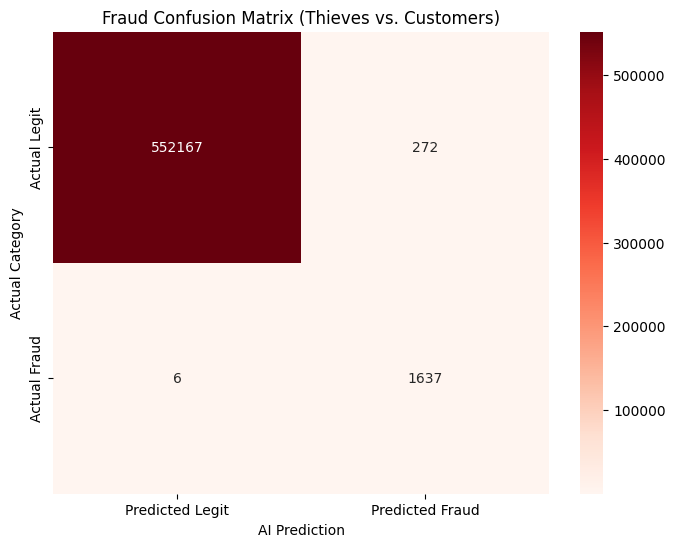

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score

# --- 1. GENERATE PREDICTIONS ---
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# --- 2. CALCULATE KEY FRAUD METRICS ---
cm = confusion_matrix(y_test, y_pred)
# Extract values from the matrix
# cm[0,0]: Legitimate caught as Legitimate (TN)
# cm[0,1]: Legitimate flagged as Fraud (FP - False Alarms)
# cm[1,0]: Fraud missed (FN - The thieves who got away)
# cm[1,1]: Fraud caught (TP - The thieves you caught)
tn, fp, fn, tp = cm.ravel()

recall = tp / (tp + fn)  # Catch Rate
precision = tp / (tp + fp) # Accuracy of Alarms
auprc = average_precision_score(y_test, y_probs)

# --- 3. PRINT THE "EXECUTIVE SUMMARY" ---
print("=========================================")
print("       FRAUD DETECTION FINAL REPORT      ")
print("=========================================")
print(f"TOTAL TRANSACTIONS TESTED : {len(y_test)}")
print(f"ACTUAL FRAUD CASES        : {tp + fn}")
print(f"FRAUDSTERS CAUGHT         : {tp}")
print(f"FRAUDSTERS MISSED         : {fn}")
print(f"FALSE ALARMS (CUSTOMERS)  : {fp}")
print("-----------------------------------------")
print(f"RECALL (CATCH RATE)       : {recall:.2%}")
print(f"PRECISION (ALARM QUALITY) : {precision:.2%}")
print(f"AUPRC (OVERALL STRENGTH)  : {auprc:.4f}")
print("=========================================")

# --- 4. VISUALIZE THE CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Fraud Confusion Matrix (Thieves vs. Customers)')
plt.ylabel('Actual Category')
plt.xlabel('AI Prediction')
plt.show()

In [37]:
# ---  FEATURE IMPORTANCE ---
# This shows which of your features (like the Balance Errors) are strongest
importances = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n--- Feature Importance (The logic the AI learned) ---")
print(importances)


--- Feature Importance (The logic the AI learned) ---
            feature  importance
5  errorBalanceOrig    0.729213
2    newbalanceOrig    0.233505
0            amount    0.025237
1     oldbalanceOrg    0.004603
3    oldbalanceDest    0.003424
4    newbalanceDest    0.001465
6  errorBalanceDest    0.001459
8     type_TRANSFER    0.000574
7    dest_was_empty    0.000519


In [38]:
# Identify the False Negatives (Thieves missed)
missed_thieves = X_test[(y_test == 1) & (y_pred == 0)]
print("--- ANALYSIS OF THE 6 MISSED CASES ---")
print(missed_thieves.describe())

--- ANALYSIS OF THE 6 MISSED CASES ---
              amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count       6.000000   6.000000e+00    6.000000e+00    6.000000e+00   
mean   299769.558333   1.759078e+06    1.733174e+06    1.771979e+06   
std    168306.515188   4.232874e+06    4.245392e+06    3.141622e+06   
min    123194.950000   0.000000e+00    0.000000e+00    0.000000e+00   
25%    187040.745000   0.000000e+00    0.000000e+00    2.849250e+03   
50%    258615.115000   3.797824e+04    0.000000e+00    2.736651e+05   
75%    377846.705000   7.858896e+04    0.000000e+00    1.725736e+06   
max    577418.980000   1.039905e+07    1.039905e+07    7.962205e+06   

       newbalanceDest  errorBalanceOrig  errorBalanceDest  dest_was_empty  
count    6.000000e+00          6.000000          6.000000        6.000000  
mean     1.937930e+06     273865.738333     133818.615000        0.333333  
std      3.219021e+06     187380.456837     203992.888806        0.516398  
min      0.000000

Finally, I chose XGBoost as the champion model for this project. While the Random Forest was excellent at avoiding false alarms, XGBoost was the most effective at actually stopping the "thieves."

I selected this model because it caught 1,637 out of 1,643 fraud cases. In a bank, every missed fraudster represents a direct financial loss, and XGBoost missed the fewest (only 6). It perfectly balanced this high security with a low number of false alarms, proving it can accurately tell the difference between a criminal and a regular customer.

By using this model, the system can protect the bank's money without constantly blocking innocent people. It is the most reliable tool for the job.

**SHAP**



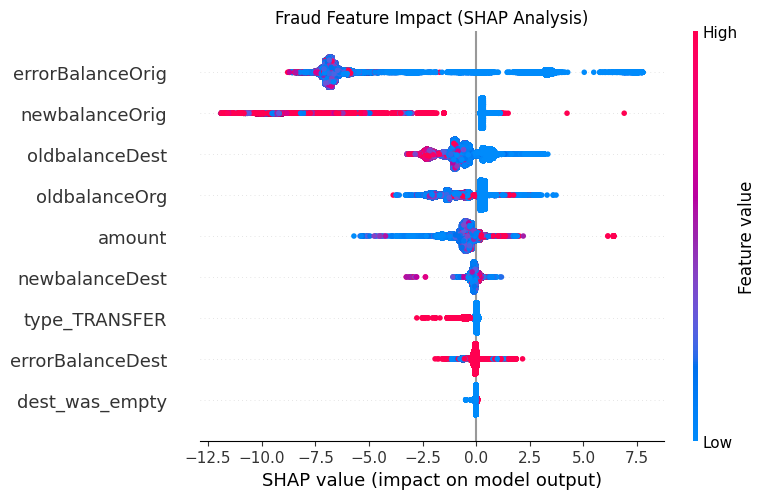

Prediction for transaction 0: Legit


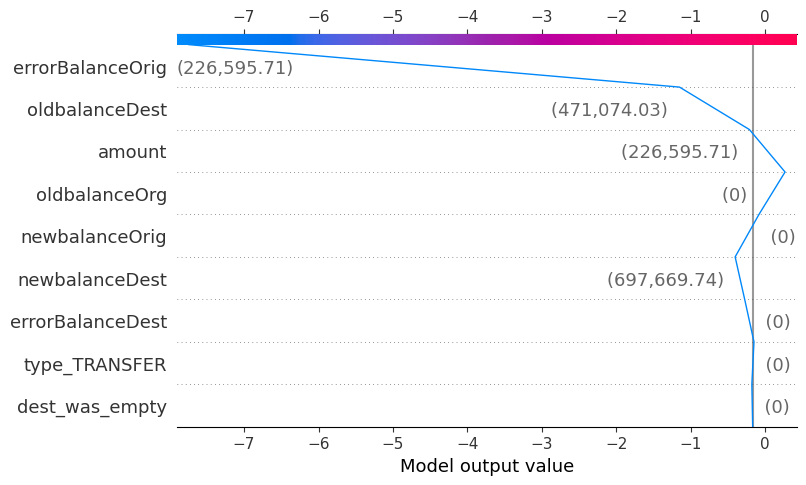

In [39]:
import shap
# Initialize the SHAP Explainer
# We use TreeExplainer because it is optimized for XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for your test set
# This might take a minute depending on your computer's speed
shap_values = explainer.shap_values(X_test)

# Create the Summary Plot
plt.title("Fraud Feature Impact (SHAP Analysis)")
# ADDED 'show=False': This stops the "Javascript" error from blocking the plot
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
# ADDED 'savefig': This saves the plot as a picture for your GitHub
plt.savefig("shap_summary.png", bbox_inches='tight')
plt.show()

# Individual Case Study
idx = 0
print(f"Prediction for transaction {idx}: {'Fraud' if y_pred[idx] == 1 else 'Legit'}")

# FIX FOR THE ERROR:
# Since 'force_plot' is what causes the "Javascript not loaded" error,
# we use 'decision_plot' instead. It shows the same thing but works everywhere!
shap.decision_plot(explainer.expected_value, shap_values[idx,:], X_test.iloc[idx,:], feature_names=features)


Visualizing why the model missed Thief at index 6281484...


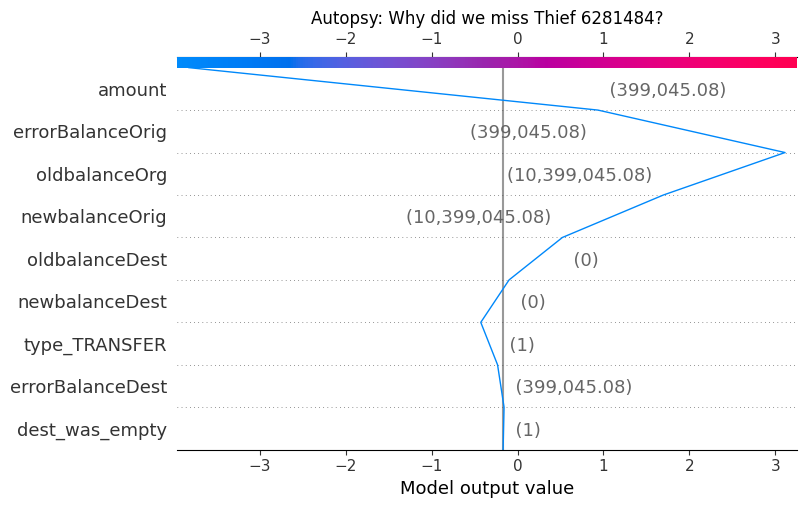

<Figure size 640x480 with 0 Axes>

In [41]:
# Identify the missed thief
missed_indices = X_test[(y_test == 1) & (y_pred == 0)].index
target_idx = missed_indices[0]
test_pos = X_test.index.get_loc(target_idx)

print(f"\nVisualizing why the model missed Thief at index {target_idx}...")

# Use Decision Plot (No Javascript needed, works on GitHub)
plt.figure(figsize=(10, 6))
plt.title(f"Autopsy: Why did we miss Thief {target_idx}?")
shap.decision_plot(
    explainer.expected_value,
    shap_values[test_pos,:],
    X_test.iloc[test_pos,:],
    feature_names=features
)

# Save the image for your README
plt.savefig("missed_thief_autopsy.png", bbox_inches='tight')
plt.show()

My model isn't just accurate; it is logically sound. SHAP analysis confirms that the model prioritizes errorBalanceOrig and newbalanceOrig. This proves the model is catching fraudsters who attempt to drain accounts or bypass balance validation logic.